# Тестирование RAG-системы

Оценка качества поиска и генерации на кастомном датасете градостроительных норм.

Метрики:
- Поиск: Hit Rate @5, MRR
- Генерация: SBERTScore, ROUGE-L F1

In [2]:
import json
from IPython.display import Markdown, display

# Сырая строка (r""") для корректной обработки слэшей в формулах
data = r"""
{
  "rag_evaluation_context": {
    "domain": "СанПиН и строительные нормативы (Градостроительство)",
    "dataset_structure": "216 тестовых кейсов",
    "pipeline": "Вопрос -> Поиск (Qdrant) -> Топ-5 чанков -> Генерация (YandexGPT) -> Сравнение с эталоном"
  },
  "metrics": [
    {
      "id": 1,
      "name": "Hit Rate @5",
      "component": "ПОИСК",
      "goal": "Находит ли поиск нужный фрагмент норматива в топ-5?",
      "formula_latex": "$$ \\text{HR@5} = \\frac{1}{N} \\sum_{i=1}^{N} \\mathbb{I}\\left( \\max_{j} \\text{sim}(R_{ij}, E_i) \\geq 0.70 \\right) $$",
      "mechanism": [
        "Берем Топ-5 чанков из Qdrant.",
        "Считаем косинусное сходство каждого с эталоном (SBERT).",
        "Если макс. сходство >= 0.70 -> успех (1), иначе (0).",
        "Усредняем по всем вопросам."
      ],
      "specifics_for_sanpin": "Критично: если норма (ПДК, расстояние) не найдена в топ-5, модель соврет.",
      "threshold": ">= 0.80"
    },
    {
      "id": 2,
      "name": "MRR",
      "component": "ПОИСК",
      "goal": "Насколько высоко в выдаче находится нужный норматив?",
      "formula_latex": "$$ \\text{MRR} = \\frac{1}{N} \\sum_{i=1}^{N} \\frac{1}{\\text{rank}_i} $$",
      "mechanism": [
        "Находим позицию первого чанка со сходством >= 0.70.",
        "Считаем обратную величину: 1/позиция (1-е место=1.0, 3-е=0.33).",
        "Если не найдено -> 0.",
        "Усредняем."
      ],
      "specifics_for_sanpin": "Показывает, не теряется ли важная норма среди шума на позициях 4-5.",
      "threshold": ">= 0.70"
    },
    {
      "id": 3,
      "name": "SBERTScore",
      "component": "ГЕНЕРАЦИЯ",
      "goal": "Смысловая точность ответа модели.",
      "formula_latex": "$$ \\text{SBERT} = \\cos(\\vec{E}_{gen}, \\vec{E}_{ref}) $$",
      "mechanism": [
        "Кодируем ответ модели и эталон в векторы (rubert-tiny2).",
        "Считаем косинус между векторами.",
        "Усредняем."
      ],
      "specifics_for_sanpin": "Важнее ROUGE: модель может перефразировать ('составляет' vs 'равно'), сохраняя смысл цифры.",
      "threshold": ">= 0.68"
    },
    {
      "id": 4,
      "name": "ROUGE-L F1",
      "component": "ГЕНЕРАЦИЯ",
      "goal": "Лексическое перекрытие (ключевые термины и цифры) через поиск общей подпоследовательности.",
      "formula_latex": "$$ P = \\frac{|LCS|}{|Gen|}, \\quad R = \\frac{|LCS|}{|Ref|}, \\quad F1 = 2 \\cdot \\frac{P \\cdot R}{P + R} $$",
      "mechanism": [
        "1. Токенизация: разбиваем текст на слова (кириллица + числа).",
        "2. Поиск LCS: алгоритм динамического программирования находит самую длинную последовательность слов, которая есть и в ответе, и в эталоне в одинаковом порядке (пропуская лишние слова).",
        "3. Расчет: Precision = длина LCS / длина ответа, Recall = длина LCS / длина эталона.",
        "4. Итог: Гармоническое среднее (F1) между точностью и полнотой."
      ],
      "specifics_for_sanpin": "Критичен для проверки точных значений. Пример: если Эталон='ПДК 0.5', Ответ='ПДК составляет 0.5', то LCS=['ПДК', '0.5'] (длина 2). Модель получила штраф за лишнее слово 'составляет', но получила баллы за сохранение порядка и цифры. Если цифра упущена — LCS резко сокращается, метрика падает.",
      "threshold": ">= 0.30"
    }
  ],
  "summary_interpretation": {
    "ideal_scenario": "HR@5 > 0.8 и SBERT > 0.7: Система находит норму и правильно её объясняет.",
    "search_failure": "HR@5 < 0.6: Проблема в эмбеддингах или чанкинге.",
    "generation_failure": "HR@5 высокий, но SBERT низкий: Модель нашла норму, но не смогла грамотно ответить.",
    "lite_vs_pro_note": "Lite часто выигрывает в ROUGE/SBERT на фактах за счет дословного копирования контекста."
  }
}
"""

# Парсим JSON
metrics_doc = json.loads(data)

# Формируем Markdown отчет
md_output = f"# Отчет по метрикам RAG: {metrics_doc['rag_evaluation_context']['domain']}\n\n"
md_output += f"**Пайплайн:** {metrics_doc['rag_evaluation_context']['pipeline']}\n\n"
md_output += "---\n\n"

for m in metrics_doc['metrics']:
    md_output += f"### {m['id']}. {m['name']} ({m['component']})\n"
    md_output += f"**Цель:** {m['goal']}\n\n"
    md_output += f"{m['formula_latex']}\n\n"
    md_output += "**Как считаем:**\n"
    for step in m['mechanism']:
        md_output += f"- {step}\n"
    
    # Добавляем блок специфики с выделением
    md_output += f"\n> **Специфика для СанПиН:** {m['specifics_for_sanpin']}\n\n"
    md_output += f"**Целевой порог:** `{m['threshold']}`\n\n"
    md_output += "---\n\n"

# Выводим результат
display(Markdown(md_output))

# Отчет по метрикам RAG: СанПиН и строительные нормативы (Градостроительство)

**Пайплайн:** Вопрос -> Поиск (Qdrant) -> Топ-5 чанков -> Генерация (YandexGPT) -> Сравнение с эталоном

---

### 1. Hit Rate @5 (ПОИСК)
**Цель:** Находит ли поиск нужный фрагмент норматива в топ-5?

$$ \text{HR@5} = \frac{1}{N} \sum_{i=1}^{N} \mathbb{I}\left( \max_{j} \text{sim}(R_{ij}, E_i) \geq 0.70 \right) $$

**Как считаем:**
- Берем Топ-5 чанков из Qdrant.
- Считаем косинусное сходство каждого с эталоном (SBERT).
- Если макс. сходство >= 0.70 -> успех (1), иначе (0).
- Усредняем по всем вопросам.

> **Специфика для СанПиН:** Критично: если норма (ПДК, расстояние) не найдена в топ-5, модель соврет.

**Целевой порог:** `>= 0.80`

---

### 2. MRR (ПОИСК)
**Цель:** Насколько высоко в выдаче находится нужный норматив?

$$ \text{MRR} = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{\text{rank}_i} $$

**Как считаем:**
- Находим позицию первого чанка со сходством >= 0.70.
- Считаем обратную величину: 1/позиция (1-е место=1.0, 3-е=0.33).
- Если не найдено -> 0.
- Усредняем.

> **Специфика для СанПиН:** Показывает, не теряется ли важная норма среди шума на позициях 4-5.

**Целевой порог:** `>= 0.70`

---

### 3. SBERTScore (ГЕНЕРАЦИЯ)
**Цель:** Смысловая точность ответа модели.

$$ \text{SBERT} = \cos(\vec{E}_{gen}, \vec{E}_{ref}) $$

**Как считаем:**
- Кодируем ответ модели и эталон в векторы (rubert-tiny2).
- Считаем косинус между векторами.
- Усредняем.

> **Специфика для СанПиН:** Важнее ROUGE: модель может перефразировать ('составляет' vs 'равно'), сохраняя смысл цифры.

**Целевой порог:** `>= 0.68`

---

### 4. ROUGE-L F1 (ГЕНЕРАЦИЯ)
**Цель:** Лексическое перекрытие (ключевые термины и цифры) через поиск общей подпоследовательности.

$$ P = \frac{|LCS|}{|Gen|}, \quad R = \frac{|LCS|}{|Ref|}, \quad F1 = 2 \cdot \frac{P \cdot R}{P + R} $$

**Как считаем:**
- 1. Токенизация: разбиваем текст на слова (кириллица + числа).
- 2. Поиск LCS: алгоритм динамического программирования находит самую длинную последовательность слов, которая есть и в ответе, и в эталоне в одинаковом порядке (пропуская лишние слова).
- 3. Расчет: Precision = длина LCS / длина ответа, Recall = длина LCS / длина эталона.
- 4. Итог: Гармоническое среднее (F1) между точностью и полнотой.

> **Специфика для СанПиН:** Критичен для проверки точных значений. Пример: если Эталон='ПДК 0.5', Ответ='ПДК составляет 0.5', то LCS=['ПДК', '0.5'] (длина 2). Модель получила штраф за лишнее слово 'составляет', но получила баллы за сохранение порядка и цифры. Если цифра упущена — LCS резко сокращается, метрика падает.

**Целевой порог:** `>= 0.30`

---



In [4]:
# Импорт библиотек
import os
import sys
import json
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

# Добавляем текущую директорию в путь для импорта модулей
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

# Импорт метрик из модуля
from metrics import (
    evaluate_case,
    #aggregate_metrics,
    THRESHOLDS,
    compute_semantic_similarity
)

In [5]:
# Конфигурация
RAG_API_BASE = "http://127.0.0.1:8003"
DATASET_PATH = "data/test_dataset_sanpin.json"
OUTPUT_REPORT = "results/evaluation_report_{}.json".format(
    datetime.now().strftime("%Y%m%d_%H%M%S")
)
TOP_K = 5

print(f"RAG API: {RAG_API_BASE}")
print(f"Датасет: {DATASET_PATH}")
print(f"Отчёт: {OUTPUT_REPORT}")

RAG API: http://127.0.0.1:8003
Датасет: data/test_dataset_sanpin.json
Отчёт: results/evaluation_report_20260308_152240.json


In [6]:
# Проверка доступности RAG-сервера
def check_rag_server(base_url: str) -> bool:
    try:
        resp = requests.get(f"{base_url}/status", timeout=10)
        return resp.status_code == 200
    except Exception as e:
        print(f"Ошибка подключения: {e}")
        return False

if not check_rag_server(RAG_API_BASE):
    raise ConnectionError(
        f"RAG-сервер недоступен по адресу {RAG_API_BASE}.\n"
        f"Запустите: python rag_server.py"
    )
print("RAG-сервер доступен")

RAG-сервер доступен


In [7]:
# Загрузка датасета
print(f"Загрузка датасета: {DATASET_PATH}")
with open(DATASET_PATH, 'r', encoding='utf-8') as f:
    dataset = json.load(f)

test_cases = dataset["test_cases"]
print(f"Загружено тестовых кейсов: {len(test_cases)}")
print(f"Метаданные: {dataset['metadata']}")

Загрузка датасета: data/test_dataset_sanpin.json
Загружено тестовых кейсов: 216
Метаданные: {'domain': 'sanpin_regulations', 'created_at': '2026-03-07T17:41:16.712889', 'num_test_cases': 216, 'source_files': ['13-2-1-3-svody-pravil_1630505371536626773.pdf', '1604211643_file_15076223214228.pdf', '39qmq037smbcw7bj6g8vqsrg1qufp1wd.pdf', 'SP-131.13330.2020.-Stroitelnaya-klimatologiya..pdf', 'SP-18.13330.2019-Proizvodstvennye-obekty.-Planirovochnaya-organizatsiya-zemelnogo-uchastka.pdf', 'SP-19.13330.2019-Selskokhozyaystvennye-predpriyatiya.-Planirovochnaya-organizatsiya-zemelnogo-uchastka..pdf', 'SP-396.1325800.2018-Ulitsy-i-dorogi-naselennykh-punktov.-Pravila-gradostroitelnogo-proektirovaniya.pdf', 'SP-42-13330-2016-Svod-pravil-Gradostroitelstvo.pdf', 'SP53_13330_2019-2023.pdf', 'SP82133302016.pdf', 'eceb31f96e34d15f1b4c7ccbfba37b22.pdf', 'sp32.13330.2018 kanalizaciyasetiisoor-snip-2.04.03-85-solidt.ru.pdf', 'sp59-13330-2020.pdf', 'СанПиН-2.2.1-2.1.1.1076-01-Гигиенические-требования-к-инс

In [8]:
# Клиент для вызова RAG API (правильный формат запроса)
def call_rag_chat(question: str, user_id: str = "evaluator", top_k: int = TOP_K) -> dict:
    payload = {
        "user_id": user_id,
        "question": question,
        "top_k": top_k,
        "include_history": False,
        "max_history_messages": 10
    }
    try:
        resp = requests.post(
            f"{RAG_API_BASE}/chat",
            json=payload,
            headers={"Content-Type": "application/json"},
            timeout=120
        )
        resp.raise_for_status()
        return resp.json()
    except Exception as e:
        return {"error": str(e), "answer": "", "sources": []}

In [9]:
# Запуск оценки по всему датасету
print("\nЗапуск оценки...\n")

all_results = []
detailed_log = []
start_time = time.time()

for i, case in enumerate(test_cases, 1):
    question = case["question"]
    expected_answer = case["expected_answer"]
    reference_text = case["reference_text"]
    
    # Вызов RAG-системы
    response = call_rag_chat(question)
    generated_answer = response.get("answer", "")
    retrieved_sources = response.get("sources", [])
    
    # Оценка метрик
    metrics = evaluate_case(
        retrieved_sources=retrieved_sources,
        reference_text=reference_text,
        generated_answer=generated_answer,
        expected_answer=expected_answer,
        top_k=TOP_K
    )
    
    all_results.append(metrics)
    
    # Лог для детального анализа
    detailed_log.append({
        "id": case["id"],
        "question": question,
        "expected_answer": expected_answer,
        "generated_answer": generated_answer,
        "metrics": metrics,
        "error": response.get("error")
    })
    
    # Прогресс в консоль
    search_ok = "OK" if metrics["search"]["hit_rate_at_5"] == 1 else "MISS"
    print(f"[{i}/{len(test_cases)}] {search_ok} "
          f"Search: HR={metrics['search']['hit_rate_at_5']}, MRR={metrics['search']['mrr']} | "
          f"Gen: SBERT={metrics['generation']['sbert_score']}, ROUGE={metrics['generation']['rouge_l_f1']}")

elapsed = time.time() - start_time
print(f"\nВремя выполнения: {elapsed:.2f} сек")


Запуск оценки...

Загрузка модели: cointegrated/rubert-tiny2


Loading weights: 100%|██████████| 55/55 [00:00<00:00, 3363.03it/s]
BertModel LOAD REPORT from: cointegrated/rubert-tiny2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[1/216] OK Search: HR=1, MRR=1.0 | Gen: SBERT=0.7859, ROUGE=0.1538
[2/216] OK Search: HR=1, MRR=1.0 | Gen: SBERT=0.8694, ROUGE=0.5714
[3/216] OK Search: HR=1, MRR=0.3333 | Gen: SBERT=0.9333, ROUGE=0.5455
[4/216] OK Search: HR=1, MRR=0.3333 | Gen: SBERT=0.7334, ROUGE=0
[5/216] OK Search: HR=1, MRR=1.0 | Gen: SBERT=0.8099, ROUGE=0.0
[6/216] OK Search: HR=1, MRR=1.0 | Gen: SBERT=0.7656, ROUGE=0.3333
[7/216] OK Search: HR=1, MRR=0.3333 | Gen: SBERT=0.7712, ROUGE=0.1714
[8/216] OK Search: HR=1, MRR=0.5 | Gen: SBERT=0.9509, ROUGE=0.6
[9/216] MISS Search: HR=0, MRR=0.0 | Gen: SBERT=0.7703, ROUGE=0
[10/216] OK Search: HR=1, MRR=1.0 | Gen: SBERT=0.9431, ROUGE=1.0
[11/216] MISS Search: HR=0, MRR=0.0 | Gen: SBERT=0.7708, ROUGE=0.6667
[12/216] OK Search: HR=1, MRR=1.0 | Gen: SBERT=0.8818, ROUGE=0.3636
[13/216] OK Search: HR=1, MRR=1.0 | Gen: SBERT=0.9024, ROUGE=0.3077
[14/216] MISS Search: HR=0, MRR=0.0 | Gen: SBERT=0.7712, ROUGE=0
[15/216] OK Search: HR=1, MRR=1.0 | Gen: SBERT=0.7999, ROUGE=0
[16

In [15]:
import numpy as np
from typing import List, Dict, Optional
def aggregate_metrics(all_results: List[Dict]) -> Dict[str, Dict[str, float]]:
    if not all_results:
        return {}
    
    hit_rates = [r["search"]["hit_rate_at_5"] for r in all_results]
    mrrs = [r["search"]["mrr"] for r in all_results]
    sberts = [r["generation"]["sbert_score"] for r in all_results]
    rouges = [r["generation"]["rouge_l_f1"] for r in all_results]
    
    return {
        "search": {
            "hit_rate_at_5": {
                "mean": round(np.mean(hit_rates), 4),
                "std": round(np.std(hit_rates), 4)
            },
            "mrr": {
                "mean": round(np.mean(mrrs), 4),
                "std": round(np.std(mrrs), 4)
            }
        },
        "generation": {
            "sbert_score": {
                "mean": round(np.mean(sberts), 4),
                "std": round(np.std(sberts), 4)
            },
            "rouge_l_f1": {
                "mean": round(np.mean(rouges), 4),
                "std": round(np.std(rouges), 4)
            }
        },
        "num_cases": len(all_results)
    }

In [16]:
# Агрегация и вывод итоговых метрик
summary = aggregate_metrics(all_results)

print("\n" + "="*70)
print("ИТОГОВЫЕ МЕТРИКИ")
print("="*70)

print("\nПОИСК:")
print(f"  Hit Rate @5:  {summary['search']['hit_rate_at_5']['mean']} +/- {summary['search']['hit_rate_at_5']['std']}  (порог >= {THRESHOLDS['hit_rate_at_5']})")
print(f"  MRR:          {summary['search']['mrr']['mean']} +/- {summary['search']['mrr']['std']}  (порог >= {THRESHOLDS['mrr']})")

print("\nГЕНЕРАЦИЯ:")
print(f"  SBERTScore:   {summary['generation']['sbert_score']['mean']} +/- {summary['generation']['sbert_score']['std']}  (порог >= {THRESHOLDS['sbert_score']})")
print(f"  ROUGE-L F1:   {summary['generation']['rouge_l_f1']['mean']} +/- {summary['generation']['rouge_l_f1']['std']}  (порог >= {THRESHOLDS['rouge_l_f1']})")

print(f"\nОбработано кейсов: {summary['num_cases']}")


ИТОГОВЫЕ МЕТРИКИ

ПОИСК:
  Hit Rate @5:  0.8704 +/- 0.3359  (порог >= 0.8)
  MRR:          0.7496 +/- 0.375  (порог >= 0.7)

ГЕНЕРАЦИЯ:
  SBERTScore:   0.844 +/- 0.0929  (порог >= 0.68)
  ROUGE-L F1:   0.2912 +/- 0.3099  (порог >= 0.3)

Обработано кейсов: 216


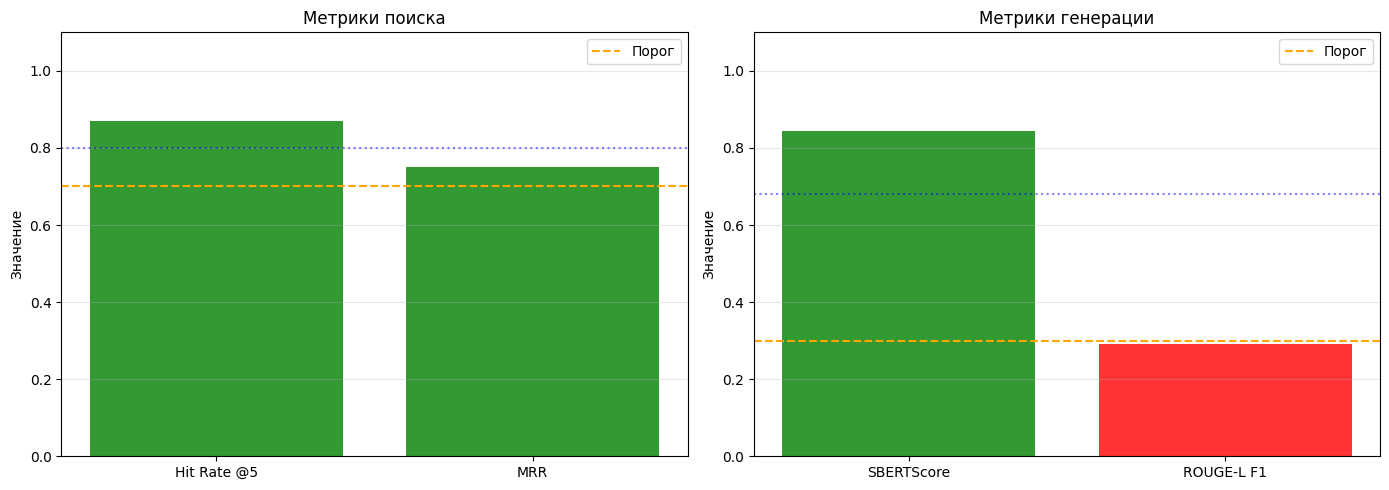

График сохранён: results/metrics_chart_v0.png


In [17]:
# Визуализация результатов
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# График 1: Поиск
search_metrics = ["Hit Rate @5", "MRR"]
search_values = [
    summary["search"]["hit_rate_at_5"]["mean"],
    summary["search"]["mrr"]["mean"]
]
search_thresholds = [
    THRESHOLDS["hit_rate_at_5"],
    THRESHOLDS["mrr"]
]
search_colors = ["green" if v >= t else "red" for v, t in zip(search_values, search_thresholds)]

axes[0].bar(search_metrics, search_values, color=search_colors, alpha=0.8)
axes[0].axhline(y=0.7, color="orange", linestyle="--", label="Порог")
axes[0].axhline(y=0.8, color="blue", linestyle=":", alpha=0.5)
axes[0].set_ylabel("Значение")
axes[0].set_title("Метрики поиска")
axes[0].set_ylim(0, 1.1)
axes[0].grid(axis="y", alpha=0.3)
axes[0].legend()

# График 2: Генерация
gen_metrics = ["SBERTScore", "ROUGE-L F1"]
gen_values = [
    summary["generation"]["sbert_score"]["mean"],
    summary["generation"]["rouge_l_f1"]["mean"]
]
gen_thresholds = [
    THRESHOLDS["sbert_score"],
    THRESHOLDS["rouge_l_f1"]
]
gen_colors = ["green" if v >= t else "red" for v, t in zip(gen_values, gen_thresholds)]

axes[1].bar(gen_metrics, gen_values, color=gen_colors, alpha=0.8)
axes[1].axhline(y=0.3, color="orange", linestyle="--", label="Порог")
axes[1].axhline(y=0.68, color="blue", linestyle=":", alpha=0.5)
axes[1].set_ylabel("Значение")
axes[1].set_title("Метрики генерации")
axes[1].set_ylim(0, 1.1)
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout()
os.makedirs("results", exist_ok=True)
plt.savefig("results/metrics_chart_v0.png", dpi=300, bbox_inches="tight")
plt.show()
print("График сохранён: results/metrics_chart_v0.png")

In [18]:
# Анализ неудачных кейсов (для отладки)
failed_search = [log for log in detailed_log if log["metrics"]["search"]["hit_rate_at_5"] == 0]
failed_gen = [log for log in detailed_log if log["metrics"]["generation"]["sbert_score"] < THRESHOLDS["sbert_score"]]

print(f"\nАнализ неудач:")
print(f"  Провал поиска: {len(failed_search)} из {len(test_cases)} ({100*len(failed_search)/len(test_cases):.1f}%)")
print(f"  Провал генерации: {len(failed_gen)} из {len(test_cases)} ({100*len(failed_gen)/len(test_cases):.1f}%)")


Анализ неудач:
  Провал поиска: 28 из 216 (13.0%)
  Провал генерации: 5 из 216 (2.3%)


In [19]:
# Альтернативный вариант: метрики + пороги в одном уровне
metrics_with_thresholds = {
    "hit_rate_at_5": {
        "value": summary["search"]["hit_rate_at_5"]["mean"],
        "threshold": THRESHOLDS["hit_rate_at_5"]
    },
    "mrr": {
        "value": summary["search"]["mrr"]["mean"],
        "threshold": THRESHOLDS["mrr"]
    },
    "sbert_score": {
        "value": summary["generation"]["sbert_score"]["mean"],
        "threshold": THRESHOLDS["sbert_score"]
    },
    "rouge_l_f1": {
        "value": summary["generation"]["rouge_l_f1"]["mean"],
        "threshold": THRESHOLDS["rouge_l_f1"]
    }
}

with open("results/metrics_with_thresholds.json", 'w', encoding='utf-8') as f:
    json.dump(metrics_with_thresholds, f, ensure_ascii=False, indent=2)

# Визуализация результатов тестирования моделей

Найдено файлов: 4


,model,hit_rate_at_5,mrr,sbert_score,rouge_l_f1
0,yandexgpt-lite_5_baseline,0.4950,0.3150,0.4800,0.0500
1,yandexgpt-lite_5_optimal_chunk_hyperparametrs,0.8565,0.6789,0.7905,0.2772
2,yandexgpt_pro_5_optimal_chunk_hyperparametrs,0.8565,0.6789,0.7612,0.1883
3,yandexgpt-lite_5_pipeline,0.8704,0.7496,0.8440,0.2912



График сохранен: results\comparison_all_models_vertical.png


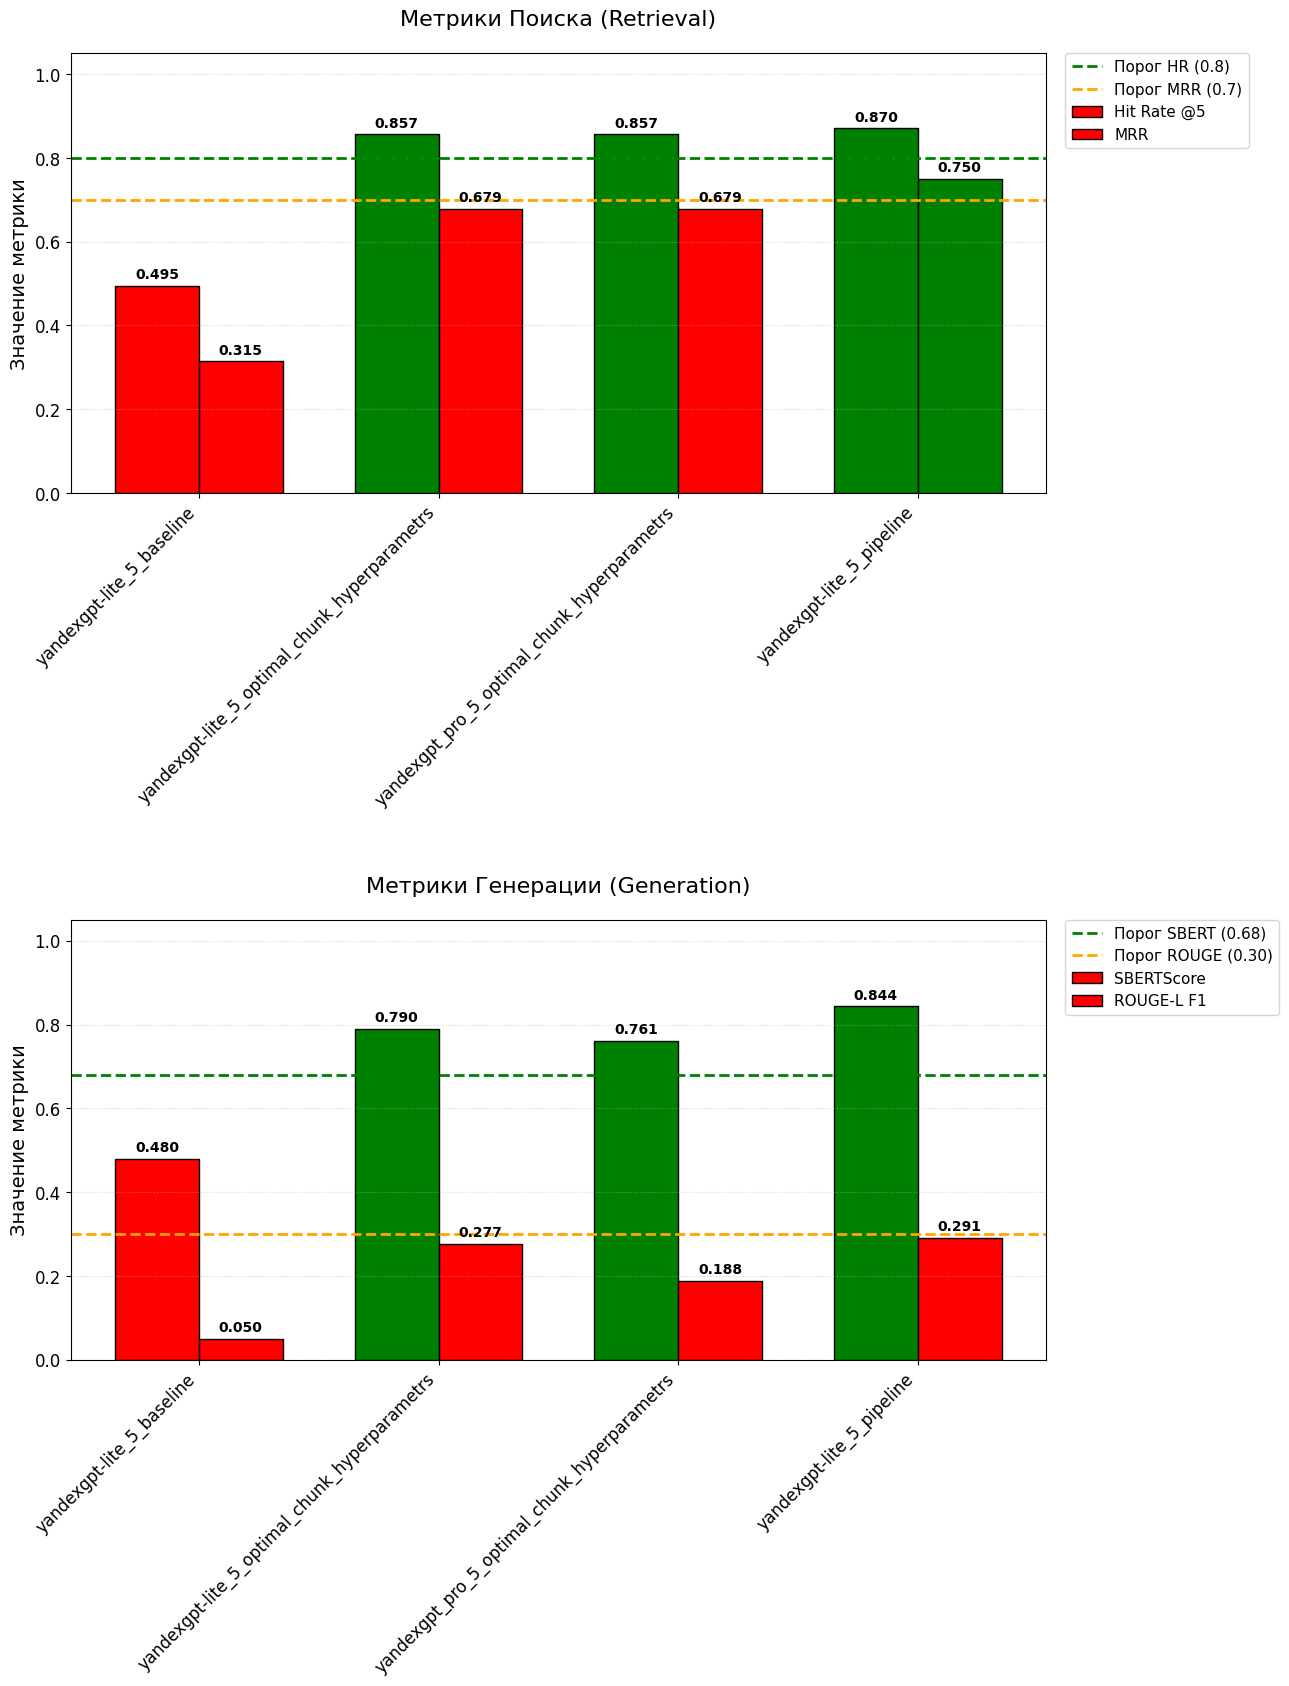

In [26]:
import os
import json
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Настройки отображения графиков
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['legend.fontsize'] = 11

# =====================================================
# 1. ЗАГРУЗКА ДАННЫХ
# =====================================================

results_folder = "results"
pattern = os.path.join(results_folder, "*_metrics_*.json")
files = sorted(glob.glob(pattern))

if not files:
    print(f"Файлы не найдены в папке '{results_folder}'. Проверьте путь или шаблон имени.")
else:
    print(f"Найдено файлов: {len(files)}")
    
    data_rows = []
    
    for file_path in files:
        filename = os.path.basename(file_path)
        # Извлечение имени модели
        parts = filename.replace('.json', '').split('_')
        if len(parts) > 2:
            model_name = "_".join(parts[2:]) 
        else:
            model_name = filename
            
        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)
        
        row = {
            "model": model_name,
            "hit_rate_at_5": data["hit_rate_at_5"]["value"],
            "mrr": data["mrr"]["value"],
            "sbert_score": data["sbert_score"]["value"],
            "rouge_l_f1": data["rouge_l_f1"]["value"]
        }
        data_rows.append(row)

    df = pd.DataFrame(data_rows)
    
    # Отображаем таблицу
    numeric_cols = ['hit_rate_at_5', 'mrr', 'sbert_score', 'rouge_l_f1']
    display(df.style.format({col: "{:.4f}" for col in numeric_cols}).background_gradient(subset=numeric_cols, cmap='RdYlGn'))

    # =====================================================
    # 2. ВИЗУАЛИЗАЦИЯ
    # =====================================================
    
    # Увеличили ширину фигуры (16 вместо 14), чтобы легенда влезла сбоку
    fig, axes = plt.subplots(2, 1, figsize=(16, 18))
    
    x = np.arange(len(df))
    width = 0.35
    
    # --- ГРАФИК 1: ПОИСК ---
    ax1 = axes[0]
    
    hr_colors = ['green' if v >= 0.8 else 'red' for v in df['hit_rate_at_5']]
    mrr_colors = ['green' if v >= 0.7 else 'red' for v in df['mrr']]
    
    bars1_1 = ax1.bar(x - width/2, df['hit_rate_at_5'], width, label='Hit Rate @5', color=hr_colors, edgecolor='black')
    bars1_2 = ax1.bar(x + width/2, df['mrr'], width, label='MRR', color=mrr_colors, edgecolor='black')
    
    ax1.axhline(y=0.8, color='green', linestyle='--', linewidth=2, label='Порог HR (0.8)')
    ax1.axhline(y=0.7, color='orange', linestyle='--', linewidth=2, label='Порог MRR (0.7)')
    
    ax1.set_ylabel('Значение метрики')
    ax1.set_title('Метрики Поиска (Retrieval)', pad=20)
    ax1.set_xticks(x)
    ax1.set_xticklabels(df['model'], rotation=45, ha='right')
    ax1.set_ylim(0, 1.05)
    ax1.grid(axis='y', linestyle=':', alpha=0.5)
    
    # ЛЕГЕНДА СНАРУЖИ (Справа сверху)
    ax1.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=True, shadow=False)
    
    # Подписи значений
    for bar in bars1_1:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')
    for bar in bars1_2:
        height = bar.get_height()
        ax1.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')

    # --- ГРАФИК 2: ГЕНЕРАЦИЯ ---
    ax2 = axes[1]
    
    sbert_colors = ['green' if v >= 0.68 else 'red' for v in df['sbert_score']]
    rouge_colors = ['green' if v >= 0.30 else 'red' for v in df['rouge_l_f1']]
    
    bars2_1 = ax2.bar(x - width/2, df['sbert_score'], width, label='SBERTScore', color=sbert_colors, edgecolor='black')
    bars2_2 = ax2.bar(x + width/2, df['rouge_l_f1'], width, label='ROUGE-L F1', color=rouge_colors, edgecolor='black')
    
    ax2.axhline(y=0.68, color='green', linestyle='--', linewidth=2, label='Порог SBERT (0.68)')
    ax2.axhline(y=0.30, color='orange', linestyle='--', linewidth=2, label='Порог ROUGE (0.30)')
    
    ax2.set_ylabel('Значение метрики')
    ax2.set_title('Метрики Генерации (Generation)', pad=20)
    ax2.set_xticks(x)
    ax2.set_xticklabels(df['model'], rotation=45, ha='right')
    ax2.set_ylim(0, 1.05)
    ax2.grid(axis='y', linestyle=':', alpha=0.5)
    
    # ЛЕГЕНДА СНАРУЖИ (Справа сверху)
    ax2.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, frameon=True, shadow=False)
    
    # Подписи значений
    for bar in bars2_1:
        height = bar.get_height()
        ax2.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')
    for bar in bars2_2:
        height = bar.get_height()
        ax2.annotate(f'{height:.3f}', xy=(bar.get_x() + bar.get_width()/2, height),
                     xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')

    # tight_layout с запасом справа для легенды (pad=4.0, rect=[0, 0, 0.85, 1])
    # Но проще использовать bbox_inches='tight' при сохранении, а здесь просто оставить запас
    plt.tight_layout(rect=[0, 0, 0.88, 1], pad=4.0)
    
    output_image = os.path.join(results_folder, "comparison_all_models_vertical.png")
    plt.savefig(output_image, dpi=300, bbox_inches='tight')
    print(f"\nГрафик сохранен: {output_image}")
    
    plt.show()

# Схема RAG-пайплайна

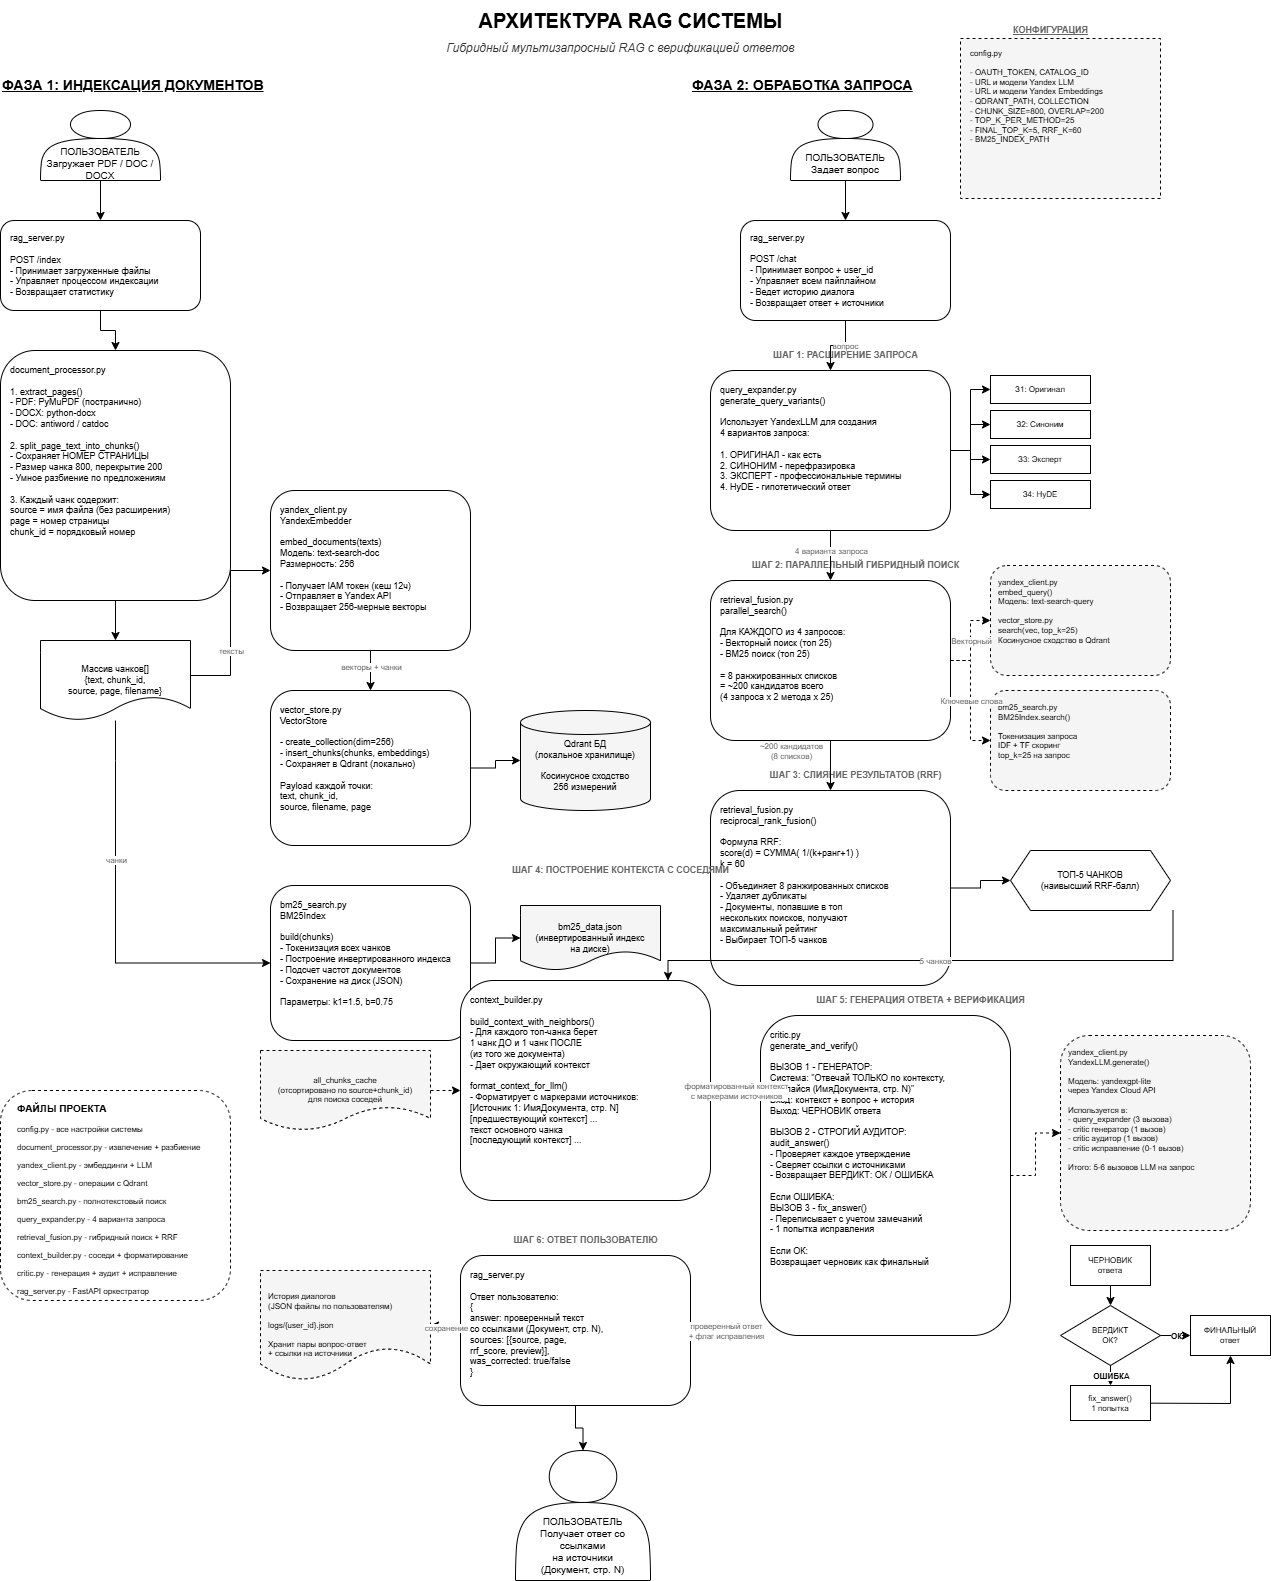

In [25]:
from IPython.display import Image, display
import os

# Путь к файлу
image_path = "rag_core_final/Схема_RAG_системы.png"

# Проверка существования файла
if os.path.exists(image_path):
    # Отображение изображения
    display(Image(filename=image_path))
else:
    print(f"Ошибка: Файл не найден по пути '{image_path}'")
    print("Проверьте:")
    print(f"1. Существует ли папка 'rag_core_final' в текущей директории: {os.getcwd()}")
    print("2. Правильность написания имени файла (учитывая регистр и символы).")
    
    # Попытка найти файл похожим именем (для отладки)
    import glob
    found_files = glob.glob("**/*Схема*.png", recursive=True)
    if found_files:
        print("\nНайдены похожие файлы:")
        for f in found_files:
            print(f" - {f}")

# Тестирование RAG-пайплайна эмпирическим путем

In [ ]:
import requests
import json
import time

RAG_API_URL = "http://localhost:8003"

question = "Что не допускается размещать в санитарно-защитной зоне?"
#question = "Как следует выполнять гидравлический расчет канализационных сетей?"
#question = "Что можно построить рядом со школой?"
#question = "На какой срок службу следует проектировать сооружения и трубопроводы?"
#question = "Что следует учитывать для проектируемых новых жилых районов в дополнение к расчетному балансовому водопотреблению?"
user_id = "test_user_01"

payload = {
    "user_id": user_id,
    "question": question,
    "top_k": 5,
    "include_history": True,
    "max_history_messages": 10
}

print(f"Вопрос: {question}")
print(f"Отправка запроса...")
print()

t0 = time.time()
response = requests.post(f"{RAG_API_URL}/chat", json=payload, timeout=300)
elapsed = time.time() - t0

if response.status_code == 200:
    data = response.json()

    print("=" * 70)
    print("ОТВЕТ")
    print("=" * 70)
    print(data["answer"])
    print()

    print("-" * 70)
    print("ИСТОЧНИКИ")
    print("-" * 70)
    for i, src in enumerate(data["sources"], 1):
        print(f"  {i}. {src['source']} (стр. {src.get('page', '?')}) | RRF: {src.get('rrf_score', '-')}")
        if src.get("preview"):
            print(f"     {src['preview'][:100]}...")
    print()

    print(f"Исправлен критиком: {'Да' if data.get('was_corrected') else 'Нет'}")
    print(f"Время ответа: {data.get('elapsed_seconds', round(elapsed, 2))} сек")
else:
    print(f"Ошибка {response.status_code}: {response.text}")

Вопрос: Что не допускается размещать в санитарно-защитной зоне?
Отправка запроса...

ОТВЕТ
В санитарно-защитной зоне не допускается размещать:
* жилую застройку, включая отдельные жилые дома;
* ландшафтно-рекреационные зоны, зоны отдыха;
* территории курортов, санаториев и домов отдыха;
* территории садоводческих товариществ и коттеджной застройки;
* коллективных или индивидуальных дачных и садово-огородных участков;
* другие территории с нормируемыми показателями качества среды обитания;
* спортивные сооружения, детские площадки;
* образовательные и детские учреждения;
* лечебно-профилактические и оздоровительные учреждения общего пользования.

(Источник: [Source 1: 46023c36_ПОСТАНОВЛЕНИЕ от 25 сентября 2007 г. N 74, p. 9])

----------------------------------------------------------------------
ИСТОЧНИКИ
----------------------------------------------------------------------
  1. 46023c36_ПОСТАНОВЛЕНИЕ от 25 сентября 2007 г. N 74 (стр. 9) | RRF: 0.1309
     V. Режим территории санитарн